In [44]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load data
df = pd.read_csv("nightingale.csv")

# Rename columns
df = df.rename(columns={
    'Disease.rate': 'DiseaseMortalityRate',
    'Wounds.rate': 'WoundsMortalityRate',
    'Other.rate': 'OtherMortalityRate'
})

df.head()

,S/No,Date,Month,Year,Army,Disease,Wounds,Other,DiseaseMortalityRate,WoundsMortalityRate,OtherMortalityRate
0,1,1854-04-01,April,1854,8571,1,0,5,1.4,0.0,7.0
1,2,1854-05-01,May,1854,23333,12,0,9,6.2,0.0,4.6
2,3,1854-06-01,June,1854,28333,11,0,6,4.7,0.0,2.5
3,4,1854-07-01,July,1854,28722,359,0,23,150.0,0.0,9.6
4,5,1854-08-01,August,1854,30246,828,1,30,328.5,0.4,11.9


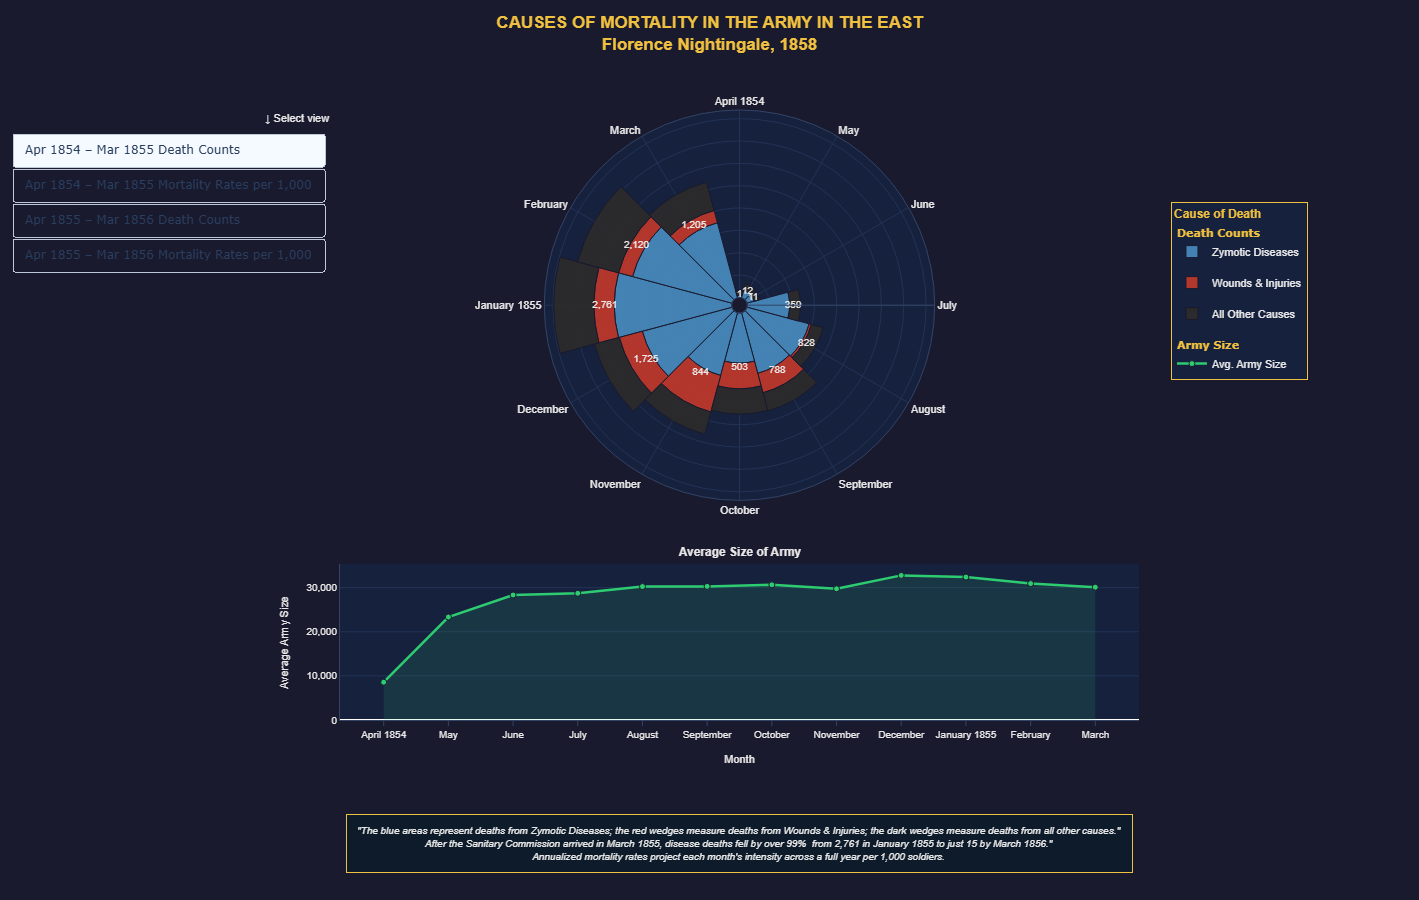

Saved


In [55]:
# Extract the month rows to a seperate dataframe
period1 = df.iloc[:12].copy()  # April 1854 to March 1855
period2 = df.iloc[12:].copy()  # April 1855 to March 1856

# Define Variables for Colors
hex_diseases = "#4A90C4"
hex_wounds = "#C0392B"
hex_other = "#2C2C2C"
hex_disease_mortalityrate = "#F39C12"
hex_wounds_mortalityrate  = "#E74C3C"
hex_other_mortalityrate   = "#7F8C8D"
hex_army         = "#2ECC71"
hex_background = "#1A1A2E" 
hex_panel = "#16213E"
hex_title = "#F0C040"
hex_text = "#E8E8E8"
hex_subtext = "#AAAACC"

# Convert values to a wedge radius
def scale(x):
    return np.sqrt(max(float(x), 0))

# Mapping Month Labels (Rose Chart)
month_labels = []
for _, row in df.iterrows():
    if row['Month'] in ['April', 'January']:
        month_labels.append(f"{row['Month']} {int(row['Year'])}")
    else:
        month_labels.append(row['Month'])

# Split 24 month labels into 2 lists(one per period)(Rose Chart)
p1_labels = month_labels[:12]
p2_labels = month_labels[12:]

# Mapping Month Labels (Line Chart's x-axis)
def plain_labels(data):
    labels = []
    for row in data.itertuples():
        if row.Month in ['April', 'January']:
            labels.append(f"{row.Month} {int(row.Year)}")
        else:
            labels.append(row.Month)
    return labels

# Split 24 month labels into 2 lists(one per period)(Line Chart)
p1_plain = plain_labels(period1)
p2_plain = plain_labels(period2)


thetas = list(range(0, 360, 30))

# Mapping Tooltips(Rose Chart)
def hover(row, cause):
    return (
        f"<b>{row.Month} {int(row.Year)}</b><br><br>"
        f"<b>Cause: {cause}</b><br>"
        f"Disease deaths : <b>{int(row.Disease):,}</b><br>"
        f"Wound deaths   : <b>{int(row.Wounds):,}</b><br>"
        f"Other deaths   : <b>{int(row.Other):,}</b><br>"
        f"Army size      : <b>{int(row.Army):,}</b><br><br>"
        f"<b>Mortality rates per 1,000 soldiers:</b><br>"
        f"Disease rate   : <b>{row.DiseaseMortalityRate}</b><br>"
        f"Wounds rate    : <b>{row.WoundsMortalityRate}</b><br>"
        f"Other rate     : <b>{row.OtherMortalityRate}</b>"
    )

# Define Reusable function for controlling the interface (Both Rose & Line Chart)
def make_polar_traces(data, visible, show_legend, mode):
    if mode == 'counts':
        r_d     = [scale(v) for v in data['Disease']]
        r_w     = [scale(v) for v in data['Wounds']]
        r_o     = [scale(v) for v in data['Other']]
        c_d, c_w, c_o         = hex_diseases, hex_wounds, hex_other
        name_d, name_w, name_o = "Zymotic Diseases", "Wounds & Injuries", "All Other Causes"
        grp_d, grp_w, grp_o   = "disease_count", "wounds_count", "other_count"
        lbl_r   = [scale(v) * 1.08 for v in data['Disease']]
        lbl_tx  = [f"{int(v):,}" for v in data['Disease']]
        lbl_col = hex_text
        grp_title = "<b>Death Counts</b>"
    else:
        r_d     = [scale(v) for v in data['DiseaseMortalityRate']]
        r_w     = [scale(v) for v in data['WoundsMortalityRate']]
        r_o     = [scale(v) for v in data['OtherMortalityRate']]
        c_d, c_w, c_o         = hex_disease_mortalityrate, hex_wounds_mortalityrate, hex_other_mortalityrate
        name_d  = "Disease Mortality Rate"
        name_w  = "Wounds Mortality Rate"
        name_o  = "Other Mortality Rate"
        grp_d, grp_w, grp_o   = "disease_rate", "wounds_rate", "other_rate"
        lbl_r   = [scale(v) * 1.08 for v in data['DiseaseMortalityRate']]
        lbl_tx  = [f"{v}" for v in data['DiseaseMortalityRate']]
        lbl_col = hex_text
        grp_title = "<b>Mortality Rates per 1,000</b>"

    t_disease = go.Barpolar(
        r=r_d,
        theta=thetas,
        width=[30] * 12,
        marker=dict(color=c_d, line=dict(color=hex_background, width=1)),
        opacity=0.88,
        name=name_d,
        customdata=[[hover(row, name_d)] for row in data.itertuples()],
        hovertemplate="%{customdata[0]}<extra></extra>",
        visible=visible,
        showlegend=show_legend,
        legendgroup=grp_d,
        legendgrouptitle=dict(
            text=grp_title,
            font=dict(color=hex_title, size=11)
    ),
  )
    t_wounds = go.Barpolar(
        r=r_w,
        theta=thetas,
        width=[30] * 12,
        marker=dict(color=c_w, line=dict(color=hex_background, width=1)),
        opacity=0.92,
        name=name_w,
        customdata=[[hover(row, name_w)] for row in data.itertuples()],
        hovertemplate="%{customdata[0]}<extra></extra>",
        visible=visible,
        showlegend=show_legend,
        legendgroup=grp_w,
    )
    t_other = go.Barpolar(
        r=r_o,
        theta=thetas,
        width=[30] * 12,
        marker=dict(color=c_o, line=dict(color=hex_background, width=1)),
        opacity=0.95,
        name=name_o,
        customdata=[[hover(row, name_o)] for row in data.itertuples()],
        hovertemplate="%{customdata[0]}<extra></extra>",
        visible=visible,
        showlegend=show_legend,
        legendgroup=grp_o,
    )
    t_labels = go.Scatterpolar(
        r=lbl_r,
        theta=thetas,
        mode="text",
        text=lbl_tx,
        textfont=dict(color=lbl_col, size=10, family="Arial"),
        hoverinfo="skip",                   
        visible=visible,
        showlegend=False,
        name="labels",
    )
    return [t_disease, t_wounds, t_other, t_labels]

def make_army_traces(data, x_labels, visible):
    t_fill = go.Scatter(
        x=x_labels,
        y=data['Army'].tolist(),
        mode='none',
        fill='tozeroy',
        fillcolor='rgba(46, 204, 113, 0.12)',
        hoverinfo='skip',
        showlegend=False,
        visible=visible,
        name='army_fill',
    )
    t_line = go.Scatter(
        x=x_labels,
        y=data['Army'].tolist(),
        mode='lines+markers',
        line=dict(color=hex_army, width=2.5),
        marker=dict(size=6, color=hex_army,
                    line=dict(color=hex_background, width=1)),
        name='Avg. Army Size',
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Average army size: <b>%{y:,}</b><extra></extra>"
        ),
        showlegend=visible,   
        legendgroup="army",
        legendgrouptitle=dict(
            text="<b>Army Size</b>",
            font=dict(color=hex_title, size=11)
        ),
        visible=visible,
    )
    return [t_fill, t_line]


# Define the structure of the interface
fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.68, 0.32],
    specs=[[{"type": "polar"}],
           [{"type": "xy"}]],
    vertical_spacing=0.20,
)

# Mapping out the Traces for both Rose and Line Charts 
tp1_counts = make_polar_traces(period1, visible=True,  show_legend=True,  mode='counts')
tp2_counts = make_polar_traces(period2, visible=False, show_legend=False, mode='counts')
tp1_rates  = make_polar_traces(period1, visible=False, show_legend=False, mode='rates')
tp2_rates  = make_polar_traces(period2, visible=False, show_legend=False, mode='rates')
ta1        = make_army_traces(period1, p1_plain, visible=True)
ta2        = make_army_traces(period2, p2_plain, visible=False)

for t in tp1_counts + tp2_counts + tp1_rates + tp2_rates:
    fig.add_trace(t, row=1, col=1)
for t in ta1 + ta2:
    fig.add_trace(t, row=2, col=1)

# Mapping out the Visibility Arrays for both Rose and Line Charts
vis_p1_counts = [True, True, True, True,   False,False,False,False,  False,False,False,False,  False,False,False,False,  True, True,  False,False]
vis_p2_counts = [False,False,False,False,  True, True, True, True,   False,False,False,False,  False,False,False,False,  False,False, True, True ]
vis_p1_rates  = [False,False,False,False,  False,False,False,False,  True, True, True, True,   False,False,False,False,  True, True,  False,False]
vis_p2_rates  = [False,False,False,False,  False,False,False,False,  False,False,False,False,  True, True, True, True,   False,False, True, True ]

leg_p1_counts = [True, True, True, False,  False,False,False,False,  False,False,False,False,  False,False,False,False,  False,True,  False,False]
leg_p2_counts = [False,False,False,False,  True, True, True, False,  False,False,False,False,  False,False,False,False,  False,False, False,True ]
leg_p1_rates  = [False,False,False,False,  False,False,False,False,  True, True, True, False,  False,False,False,False,  False,True,  False,False]
leg_p2_rates  = [False,False,False,False,  False,False,False,False,  False,False,False,False,  True, True, True, False,  False,False, False,True ]


# Customizing Navigation Buttons
fig.update_layout(
    updatemenus=[
        dict(
        type="buttons",
        direction="down",
        active=0,    
        x=-0.02, xanchor="right",
        y=0.85,  yanchor="middle",
        buttons=[
            dict(
                label="Apr 1854 – Mar 1855\nDeath Counts",
                method="update",
                args=[
                    {"visible": vis_p1_counts, "showlegend": leg_p1_counts},
                    {"polar.angularaxis.ticktext": p1_labels,
                     "title.text": (
                         "<b>CAUSES OF MORTALITY IN THE ARMY IN THE EAST</b><br>"
                         "<b>Florence Nightingale, 1858</b><br>"
                         "<sup>April 1854 – March 1855  ·  The Crisis Year  ·  Death Counts</sup>"
                     )
                    },
                ],
            ),
            dict(
                label="Apr 1854 – Mar 1855\nMortality Rates per 1,000",
                method="update",
                args=[
                    {"visible": vis_p1_rates, "showlegend": leg_p1_rates},
                    {"polar.angularaxis.ticktext": p1_labels,
                     "title.text": (
                         "<b>CAUSES OF MORTALITY IN THE ARMY IN THE EAST</b><br>"
                         "<b>Florence Nightingale, 1858</b><br>"
                         "<sup>April 1854 – March 1855  ·  The Crisis Year  ·  Annual Mortality Rate per 1,000 Soldiers</sup>"
                     )},
                ],
            ),
            dict(
                label="Apr 1855 – Mar 1856\nDeath Counts",
                method="update",
                args=[
                    {"visible": vis_p2_counts, "showlegend": leg_p2_counts},
                    {"polar.angularaxis.ticktext": p2_labels,
                     "title.text": (
                         "<b>CAUSES OF MORTALITY IN THE ARMY IN THE EAST</b><br>"
                         "<b>Florence Nightingale, 1858</b><br>"
                         "<sup>April 1855 – March 1856  ·  After Sanitary Reform  ·  Death Counts</sup>"
                     )},
                ],
            ),
            dict(
                label="Apr 1855 – Mar 1856\nMortality Rates per 1,000",
                method="update",
                args=[
                    {"visible": vis_p2_rates, "showlegend": leg_p2_rates},
                    {"polar.angularaxis.ticktext": p2_labels,
                     "title.text": (
                         "<b>CAUSES OF MORTALITY IN THE ARMY IN THE EAST</b><br>"
                         "<b>Florence Nightingale, 1858</b><br>"
                         "<sup>April 1855 – March 1856  ·  After Sanitary Reform  ·  Annual Mortality Rate per 1,000 Soldiers</sup>"
                     )},
                ],
            ),
        ],
    )]
)

# Customizing the Rose Chart
fig.update_layout(
    polar=dict(
        bgcolor=hex_panel,
        domain=dict(y=[0.36, 1.0]),
        angularaxis=dict(
            tickmode="array",
            tickvals=thetas,
            ticktext=p1_labels,
            direction="clockwise",      
            rotation=90,               
            tickfont=dict(color=hex_text, size=11, family="Arial"),
            linecolor="#334466",
            gridcolor="#223355",
            ticklen=5,
        ),
        radialaxis=dict(
            visible=True,
            showticklabels=False,       
            gridcolor="#223355",
            linecolor="#334466",
        ),
        hole=0.04,                     
    ),
)

# Customizing the Line Chart
fig.update_xaxes(
    title=dict(text="Month", font=dict(color=hex_text, size=11, family="Arial")),
    tickfont=dict(color=hex_text, size=10, family="Arial"),
    linecolor="#334466",
    gridcolor="#223355",
    showgrid=False,
    ticks="outside",
    ticklen=5,
    tickcolor="#334466",
    row=2, col=1,
)
fig.update_yaxes(
    title=dict(text="Average Army Size", font=dict(color=hex_text, size=11, family="Arial")),
    tickfont=dict(color=hex_text, size=10, family="Arial"),
    gridcolor="#223355",
    linecolor="#334466",
    tickformat=",",
    row=2, col=1,
)

# Customizing the Overall Layout
fig.update_layout(
    title=dict(
        text=(
            "<b>CAUSES OF MORTALITY IN THE ARMY IN THE EAST</b><br>"
            "<b>Florence Nightingale, 1858</b><br>"
        ),
        x=0.5, xanchor="center",
        y=0.98, yanchor="top",
        font=dict(color=hex_title, size=17, family="Arial"),
        pad=dict(t=10),
    ),
    paper_bgcolor=hex_background,
    plot_bgcolor=hex_panel,
    showlegend=True,
    legend=dict(
        font=dict(color=hex_text, size=11, family="Arial"),
        bgcolor=hex_panel,
        bordercolor=hex_title,
        borderwidth=1,
        x=1.04, y=0.85,
        tracegroupgap=12,
        title=dict(
            text="<b>Cause of Death</b>",
            font=dict(color=hex_title, size=12)
        ),
    ),
    margin=dict(t=110, b=180, l=220, r=280),
    hoverlabel=dict(
        bgcolor="#0D1B2A",
        bordercolor=hex_title,
        font=dict(color=hex_text, size=12, family="Arial"),
    ),
    height=900,
    annotations=[
        dict(
            text="<b>Average Size of Army</b>",
            x=0.5, y=0.26,
            xref="paper", yref="paper",
            xanchor="center", yanchor="bottom",
            showarrow=False,
            font=dict(color=hex_text, size=12, family="Arial"),
        ),
        
        dict(
            text=(
                "<i>\"The blue areas represent deaths from Zymotic Diseases; "
                "the red wedges measure deaths from Wounds & Injuries; "
                "the dark wedges measure deaths from all other causes.\"<br>"
                "After the Sanitary Commission arrived in March 1855, disease deaths fell by over 99%  "
                "from 2,761 in January 1855 to just 15 by March 1856.\"<br>"
                "Annualized mortality rates project each month's intensity across a full year per 1,000 soldiers.<br>"
            ),
            x=0.5, y=-0.25,
            xref="paper", yref="paper",
            showarrow=False,
            font=dict(color=hex_text, size=10, family="Arial"),
            align="center",
            bgcolor="#0D1B2A",
            bordercolor=hex_title,
            borderwidth=1,
            borderpad=10,
        ),

        dict(
            text="↓ Select view",
            x=-0.01, y=1.00,
            xref="paper", yref="paper",
            xanchor="right", yanchor="top",
            showarrow=False,
            font=dict(color=hex_text, size=11, family="Arial"),
            align="right",
        ),
    ],
)

# Save file as html
fig.write_html('Florence_Nightingale_coxcomb.html')
fig.show()
print("Saved")